# UV Index Forecasting — Residual Correction Hybrid Models
## CNN-RF and CNN-XGB Hybrid (Colombo, Sri Lanka)

**Architecture:**
- **Stage 1:** CNN (optimal 36-lag, best hyperparameters from Section 4.2)
- **Stage 2:** RF / XGB fits the CNN residuals on the TRAIN set
- **Hybrid prediction:** ŷ_hybrid = ŷ_CNN + ŷ_residual_model

**Optimal CNN hyperparameters (from lag-window comparison):**
`filters=32, kernel_size=3, lr=0.001593, batch_size=16, epochs=30`

> **Checkpoint system:** Secondary model results saved to `checkpoint_hybrid/`. Re-running skips already-trained models.


In [1]:
# ── Cell 1 — Imports & Setup ─────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'statsmodels', 'tabulate', 'optuna', 'xgboost',
                'gdown', 'tensorflow', '--quiet'], check=False)

import os, warnings, random, pickle
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from optuna.samplers import TPESampler

import xgboost as xgb

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

from tabulate import tabulate
from IPython.display import display

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.makedirs('checkpoint_hybrid', exist_ok=True)

print('✅ Imports OK  |  TF:', tf.__version__)


✅ Imports OK  |  TF: 2.19.0


## Cell 2 — Data Loading

In [2]:
file_id = '1mpdY_wqU216R7c7h_YsHqz-bryoJARwn'
csv_url = f'https://drive.google.com/uc?export=download&id={file_id}'
df = pd.read_csv(csv_url)
print(f'Dataset shape: {df.shape}')
df.head()
df_raw = df.copy()

Dataset shape: (52584, 12)


## Cell 3 — Preprocessing

In [3]:
df = df_raw.copy()
df['DateTime'] = pd.to_datetime(
    df[['YEAR', 'MO', 'DY', 'HR']].rename(
        columns={'YEAR': 'year', 'MO': 'month', 'DY': 'day', 'HR': 'hour'}
    )
)
df = df.set_index('DateTime').drop(columns=['YEAR', 'MO', 'DY', 'HR'])

def get_monsoon_season(month):
    if month in [12, 1, 2]:         return 'Northeast Monsoon'
    elif month in [3, 4]:           return 'Inter-Monsoon 1'
    elif month in [5, 6, 7, 8, 9]:  return 'Southwest Monsoon'
    else:                           return 'Inter-Monsoon 2'

season_order = ['Northeast Monsoon', 'Inter-Monsoon 1',
                'Southwest Monsoon', 'Inter-Monsoon 2']
df['monsoon_season'] = pd.Categorical(
    df.index.month.map(get_monsoon_season),
    categories=season_order, ordered=True
)

df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
df = df[(df.index.hour >= 6) & (df.index.hour <= 17)]

df['ALLSKY_SFC_UV_INDEX'] = df['ALLSKY_SFC_UV_INDEX'].replace(-999.0, np.nan)
df['ALLSKY_SFC_UV_INDEX'] = df['ALLSKY_SFC_UV_INDEX'].interpolate(
    method='polynomial', order=3
)

monsoon_dummies = pd.get_dummies(df['monsoon_season'], prefix='monsoon', drop_first=True)
df = pd.concat([df, monsoon_dummies], axis=1).drop(columns=['monsoon_season'])

df['WD10M_sin'] = np.sin(np.deg2rad(df['WD10M']))
df['WD10M_cos'] = np.cos(np.deg2rad(df['WD10M']))
df = df.drop(columns=['WD10M'])
df = df.rename(columns={'ALLSKY_SFC_UV_INDEX': 'UV_INDEX'})

original_df = df.copy()
print(f'Preprocessed shape: {df.shape}')
df=df[["UV_INDEX"]]

Preprocessed shape: (26292, 14)


## Cell 4 — Helper Functions & 36-Lag Dataset Construction

In [4]:
N_LAGS   = 36          # Long-term window (optimal from Section 4.2)
N_TRIALS = 15          # Optuna trials for secondary models
N_SPLITS = 3           # TimeSeriesSplit folds
TARGET   = 'UV_INDEX'

# ── Metrics ──────────────────────────────────────────────────────────────────
def evaluate_metrics(y_true, y_pred, label=''):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(
        np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))
    ) * 100
    r2   = r2_score(y_true, y_pred)
    if label:
        print(f'  {label:<14s}  MSE={mse:.4f}  RMSE={rmse:.4f}  '
              f'MAE={mae:.4f}  MAPE={mape:.2f}%  R²={r2:.4f}')
    return dict(MSE=mse, RMSE=rmse, MAE=mae, MAPE=mape, R2=r2)

# ── Lag dataset builder (univariate — identical inputs to Section 4.2 CNN) ───
def build_lag_dataset(dataframe, target_col, n_lags):
    lag_dict = {f'{target_col}_lag_{k}': dataframe[target_col].shift(k)
                for k in range(1, n_lags + 1)}
    lag_df = pd.DataFrame(lag_dict, index=dataframe.index)
    lag_df[target_col] = dataframe[target_col]
    return lag_df.dropna()

# ── Chronological 80/20 split ────────────────────────────────────────────────
def chronological_split(lag_df, target_col):
    split_idx  = int(len(lag_df) * 0.8)
    split_date = lag_df.index[split_idx]
    train      = lag_df[lag_df.index < split_date]
    test       = lag_df[lag_df.index >= split_date]
    return (train.drop(columns=[target_col]), train[target_col],
            test.drop(columns=[target_col]),  test[target_col],
            split_date)

# ── Checkpoint helpers ────────────────────────────────────────────────────────
def save_ckpt(name, payload):
    path = f'checkpoint_hybrid/{name}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(payload, f)

def load_ckpt(name):
    path = f'checkpoint_hybrid/{name}.pkl'
    if os.path.exists(path):
        with open(path, 'rb') as f:
            return pickle.load(f)
    return None

# Build the 36-lag dataset
lag_df   = build_lag_dataset(original_df, TARGET, N_LAGS)
X_train, y_train, X_test, y_test, split_date = chronological_split(lag_df, TARGET)
n_features = X_train.shape[1]   # = 36

print(f'Lag window : {N_LAGS} lags')
print(f'Train size : {len(X_train):,}   Test size: {len(X_test):,}')
print(f'Split date : {split_date.date()}')
print(f'Features   : {n_features}')


Lag window : 36 lags
Train size : 21,004   Test size: 5,252
Split date : 2022-10-20
Features   : 36


## Cell 5 — Stage 1: CNN with Optimal Hyperparameters
> Trains the base CNN using the best parameters identified in Section 4.2.  
> Generates predictions on **both train and test** sets.  
> Computes **training residuals** = Actual − CNN_pred (used to train secondary models).


In [5]:
# ── Optimal CNN hyperparameters from Section 4.2 ─────────────────────────────
CNN_BEST_PARAMS = {
    'filters'     : 32,
    'kernel_size' : 3,
    'lr'          : 0.0015930522616241021,
    'batch_size'  : 16,
    'epochs'      : 30,
}

print('=' * 68)
print('  STAGE 1 — CNN (Optimal Hyperparameters from Section 4.2)')
print('=' * 68)
print('  Hyperparameters:')
for k, v in CNN_BEST_PARAMS.items():
    print(f'    {k:<20s} = {v}')

# ── Scale features ────────────────────────────────────────────────────────────
# CNN input shape: [samples, n_features, 1]
cnn_scaler = StandardScaler()
Xtr_s = cnn_scaler.fit_transform(X_train).reshape(-1, n_features, 1)
Xts_s = cnn_scaler.transform(X_test).reshape(-1, n_features, 1)
ytr   = y_train.values
yts   = y_test.values

# ── Build CNN ─────────────────────────────────────────────────────────────────
def build_cnn(filters, kernel_size, lr, n_feat):
    m = Sequential([
        Conv1D(filters,
               kernel_size=min(kernel_size, n_feat),
               activation='relu',
               padding='same',
               input_shape=(n_feat, 1)),
        MaxPooling1D(pool_size=1),
        Flatten(),
        Dense(32, activation='relu'),
        Dense(1),
    ])
    m.compile(optimizer=Adam(lr), loss='mse')
    return m

cnn_model = build_cnn(
    CNN_BEST_PARAMS['filters'],
    CNN_BEST_PARAMS['kernel_size'],
    CNN_BEST_PARAMS['lr'],
    n_features,
)

print('\n  Training CNN …')
cnn_model.fit(
    Xtr_s, ytr,
    epochs     = CNN_BEST_PARAMS['epochs'],
    batch_size = CNN_BEST_PARAMS['batch_size'],
    verbose    = 0,
    shuffle    = False,
)
print('  CNN training complete.')

# ── Predictions on TRAIN and TEST ─────────────────────────────────────────────
cnn_pred_train = cnn_model.predict(Xtr_s, verbose=0).flatten()
cnn_pred_test  = cnn_model.predict(Xts_s, verbose=0).flatten()

# ── CNN standalone metrics ────────────────────────────────────────────────────
print('\n  CNN Standalone Metrics (Test Set):')
cnn_metrics = evaluate_metrics(yts, cnn_pred_test, label='CNN (standalone)')

# ── Training residuals ────────────────────────────────────────────────────────
residuals_train = ytr - cnn_pred_train

print(f'\n  Train residual statistics:')
print(f'    Mean : {residuals_train.mean():.4f}')
print(f'    Std  : {residuals_train.std():.4f}')
print(f'    Min  : {residuals_train.min():.4f}')
print(f'    Max  : {residuals_train.max():.4f}')


  STAGE 1 — CNN (Optimal Hyperparameters from Section 4.2)
  Hyperparameters:
    filters              = 32
    kernel_size          = 3
    lr                   = 0.0015930522616241021
    batch_size           = 16
    epochs               = 30

  Training CNN …
  CNN training complete.

  CNN Standalone Metrics (Test Set):
  CNN (standalone)  MSE=0.2224  RMSE=0.4716  MAE=0.3052  MAPE=9835360.55%  R²=0.9831

  Train residual statistics:
    Mean : 0.2172
    Std  : 0.4449
    Min  : -4.0169
    Max  : 3.8250


## Cell 6 — Stage 2a: RF Residual Corrector (Optuna-tuned)
> Trains a Random Forest on the **same 36 lag features** used by the CNN,  
> with the **CNN training residuals** as the target variable.  
> Hyperparameters optimised via Optuna (TimeSeriesSplit CV).  
> Results checkpointed — re-run safely.


In [6]:
print('=' * 68)
print('  STAGE 2a — RF Residual Corrector (Optuna-tuned)')
print('=' * 68)

tscv    = TimeSeriesSplit(n_splits=N_SPLITS)
ck_rf   = load_ckpt('cnn_rf_secondary')

if ck_rf:
    print('  [SKIP] Loading RF checkpoint …')
    rf_best        = ck_rf['model']
    rf_best_params = ck_rf['best_params']
else:
    def rf_objective(trial):
        m = RandomForestRegressor(
            n_estimators      = trial.suggest_int('n_estimators', 50, 200, step=50),
            max_depth         = trial.suggest_categorical('max_depth', [None, 10, 20, 30]),
            min_samples_split = trial.suggest_int('min_samples_split', 2, 8),
            min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 4),
            max_features      = trial.suggest_categorical('max_features', ['sqrt', 'log2']),
            random_state=SEED, n_jobs=-1,
        )
        scores = []
        for tr_idx, val_idx in tscv.split(X_train):
            m.fit(X_train.iloc[tr_idx], residuals_train[tr_idx])
            pred = m.predict(X_train.iloc[val_idx])
            scores.append(mean_squared_error(residuals_train[val_idx], pred))
        return np.mean(scores)

    study_rf = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
    study_rf.optimize(rf_objective, n_trials=N_TRIALS)
    rf_best_params = study_rf.best_params

    rf_best = RandomForestRegressor(**rf_best_params, random_state=SEED, n_jobs=-1)
    rf_best.fit(X_train, residuals_train)
    save_ckpt('cnn_rf_secondary', {'model': rf_best, 'best_params': rf_best_params})

# ── RF residual predictions & hybrid output ────────────────────────────────────
rf_resid_pred_test   = rf_best.predict(X_test)
hybrid_rf_pred_test  = cnn_pred_test + rf_resid_pred_test

# ── Print RF optimal hyperparameters ─────────────────────────────────────────
print('\n  RF Optimal Hyperparameters (Secondary Model):')
rf_hp_table = [[k, v] for k, v in rf_best_params.items()]
print(tabulate(rf_hp_table, headers=['Parameter', 'Value'], tablefmt='grid'))

# ── CNN-RF Hybrid metrics ─────────────────────────────────────────────────────
print('\n  CNN-RF Hybrid Metrics (Test Set):')
cnn_rf_metrics = evaluate_metrics(yts, hybrid_rf_pred_test, label='CNN-RF (hybrid)')


  STAGE 2a — RF Residual Corrector (Optuna-tuned)

  RF Optimal Hyperparameters (Secondary Model):
+-------------------+---------+
| Parameter         | Value   |
+===================+=========+
| n_estimators      | 200     |
+-------------------+---------+
| max_depth         | 20      |
+-------------------+---------+
| min_samples_split | 2       |
+-------------------+---------+
| min_samples_leaf  | 4       |
+-------------------+---------+
| max_features      | sqrt    |
+-------------------+---------+

  CNN-RF Hybrid Metrics (Test Set):
  CNN-RF (hybrid)  MSE=0.1573  RMSE=0.3967  MAE=0.2163  MAPE=6218431.01%  R²=0.9881


## Cell 7 — Stage 2b: XGB Residual Corrector (Optuna-tuned)
> Trains an XGBoost model on the **same 36 lag features** used by the CNN,  
> with the **CNN training residuals** as the target variable.  
> Hyperparameters optimised via Optuna (TimeSeriesSplit CV).  
> Results checkpointed — re-run safely.


In [7]:
print('=' * 68)
print('  STAGE 2b — XGB Residual Corrector (Optuna-tuned)')
print('=' * 68)

ck_xgb = load_ckpt('cnn_xgb_secondary')

if ck_xgb:
    print('  [SKIP] Loading XGB checkpoint …')
    xgb_best        = ck_xgb['model']
    xgb_best_params = ck_xgb['best_params']
else:
    def xgb_objective(trial):
        m = xgb.XGBRegressor(
            n_estimators     = trial.suggest_int('n_estimators', 50, 250, step=50),
            max_depth        = trial.suggest_int('max_depth', 3, 9),
            learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            subsample        = trial.suggest_float('subsample', 0.6, 1.0),
            colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0),
            min_child_weight = trial.suggest_int('min_child_weight', 1, 6),
            objective='reg:squarederror', random_state=SEED, verbosity=0,
        )
        scores = []
        for tr_idx, val_idx in tscv.split(X_train):
            m.fit(X_train.iloc[tr_idx], residuals_train[tr_idx])
            pred = m.predict(X_train.iloc[val_idx])
            scores.append(mean_squared_error(residuals_train[val_idx], pred))
        return np.mean(scores)

    study_xgb = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
    study_xgb.optimize(xgb_objective, n_trials=N_TRIALS)
    xgb_best_params = study_xgb.best_params

    xgb_best = xgb.XGBRegressor(**xgb_best_params, random_state=SEED, verbosity=0)
    xgb_best.fit(X_train, residuals_train)
    save_ckpt('cnn_xgb_secondary', {'model': xgb_best, 'best_params': xgb_best_params})

# ── XGB residual predictions & hybrid output ──────────────────────────────────
xgb_resid_pred_test   = xgb_best.predict(X_test)
hybrid_xgb_pred_test  = cnn_pred_test + xgb_resid_pred_test

# ── Print XGB optimal hyperparameters ────────────────────────────────────────
print('\n  XGB Optimal Hyperparameters (Secondary Model):')
xgb_hp_table = [[k, v] for k, v in xgb_best_params.items()]
print(tabulate(xgb_hp_table, headers=['Parameter', 'Value'], tablefmt='grid'))

# ── CNN-XGB Hybrid metrics ────────────────────────────────────────────────────
print('\n  CNN-XGB Hybrid Metrics (Test Set):')
cnn_xgb_metrics = evaluate_metrics(yts, hybrid_xgb_pred_test, label='CNN-XGB (hybrid)')


  STAGE 2b — XGB Residual Corrector (Optuna-tuned)

  XGB Optimal Hyperparameters (Secondary Model):
+------------------+-------------+
| Parameter        |       Value |
+==================+=============+
| n_estimators     | 150         |
+------------------+-------------+
| max_depth        |   9         |
+------------------+-------------+
| learning_rate    |   0.0135118 |
+------------------+-------------+
| subsample        |   0.678393  |
+------------------+-------------+
| colsample_bytree |   0.618091  |
+------------------+-------------+
| min_child_weight |   2         |
+------------------+-------------+

  CNN-XGB Hybrid Metrics (Test Set):
  CNN-XGB (hybrid)  MSE=0.1592  RMSE=0.3990  MAE=0.2257  MAPE=16371771.15%  R²=0.9879


## Cell 8 — Performance Summary Table

In [8]:
print('\n' + '=' * 80)
print('  TABLE — Hybrid Model Performance (Colombo, 36-Lag Window)')
print('=' * 80)

def fmt(d):
    return [f'{d["MSE"]:.4f}', f'{d["RMSE"]:.4f}',
            f'{d["MAE"]:.4f}',  f'{d["MAPE"]:.2f}', f'{d["R2"]:.4f}']

table_data = [
    ['CNN (Base)',  '—']               + fmt(cnn_metrics),
    ['CNN-RF',      'RF (residual)']   + fmt(cnn_rf_metrics),
    ['CNN-XGB',     'XGB (residual)']  + fmt(cnn_xgb_metrics),
]
headers = ['Model', 'Secondary', 'MSE', 'RMSE', 'MAE', 'MAPE (%)', 'R²']
print(tabulate(table_data, headers=headers, tablefmt='grid'))

# ── Export to CSV ─────────────────────────────────────────────────────────────
perf_df = pd.DataFrame({
    'Model'     : ['CNN', 'CNN-RF', 'CNN-XGB'],
    'Secondary' : ['—', 'RF', 'XGB'],
    'MSE'       : [cnn_metrics['MSE'],     cnn_rf_metrics['MSE'],     cnn_xgb_metrics['MSE']],
    'RMSE'      : [cnn_metrics['RMSE'],    cnn_rf_metrics['RMSE'],    cnn_xgb_metrics['RMSE']],
    'MAE'       : [cnn_metrics['MAE'],     cnn_rf_metrics['MAE'],     cnn_xgb_metrics['MAE']],
    'MAPE'      : [cnn_metrics['MAPE'],    cnn_rf_metrics['MAPE'],    cnn_xgb_metrics['MAPE']],
    'R2'        : [cnn_metrics['R2'],      cnn_rf_metrics['R2'],      cnn_xgb_metrics['R2']],
})
perf_df.to_csv('Table_Hybrid_Performance_Colombo.csv', index=False)
print('\nSaved → Table_Hybrid_Performance_Colombo.csv')
display(perf_df)



  TABLE — Hybrid Model Performance (Colombo, 36-Lag Window)
+------------+----------------+--------+--------+--------+-------------+--------+
| Model      | Secondary      |    MSE |   RMSE |    MAE |    MAPE (%) |     R² |
+============+================+========+========+========+=============+========+
| CNN (Base) | —              | 0.2224 | 0.4716 | 0.3052 | 9.83536e+06 | 0.9831 |
+------------+----------------+--------+--------+--------+-------------+--------+
| CNN-RF     | RF (residual)  | 0.1573 | 0.3967 | 0.2163 | 6.21843e+06 | 0.9881 |
+------------+----------------+--------+--------+--------+-------------+--------+
| CNN-XGB    | XGB (residual) | 0.1592 | 0.399  | 0.2257 | 1.63718e+07 | 0.9879 |
+------------+----------------+--------+--------+--------+-------------+--------+

Saved → Table_Hybrid_Performance_Colombo.csv


,Model,Secondary,MSE,RMSE,MAE,MAPE,R2
0,CNN,—,0.222446,0.471641,0.305182,9.835361e+06,0.983133
1,CNN-RF,RF,0.157341,0.396662,0.216337,6.218431e+06,0.988070
2,CNN-XGB,XGB,0.159185,0.398980,0.225656,1.637177e+07,0.987930


## Cell 9 — Hyperparameter Summary Tables

In [9]:
print('=' * 68)
print('  HYPERPARAMETER SUMMARY — Stage-1: CNN')
print('=' * 68)
print(tabulate([[k, v] for k, v in CNN_BEST_PARAMS.items()],
               headers=['Parameter', 'Value'], tablefmt='grid'))

print('\n' + '=' * 68)
print('  HYPERPARAMETER SUMMARY — Stage-2: RF (Residual Corrector)')
print('=' * 68)
print(tabulate([[k, v] for k, v in rf_best_params.items()],
               headers=['Parameter', 'Value'], tablefmt='grid'))

print('\n' + '=' * 68)
print('  HYPERPARAMETER SUMMARY — Stage-2: XGB (Residual Corrector)')
print('=' * 68)
print(tabulate([[k, v] for k, v in xgb_best_params.items()],
               headers=['Parameter', 'Value'], tablefmt='grid'))

# ── Export hyperparameters to CSV ─────────────────────────────────────────────
hp_rows = []
for k, v in CNN_BEST_PARAMS.items():
    hp_rows.append({'Stage': 'CNN (Stage-1)', 'Parameter': k, 'Value': v})
for k, v in rf_best_params.items():
    hp_rows.append({'Stage': 'RF (Stage-2, CNN-RF)', 'Parameter': k, 'Value': v})
for k, v in xgb_best_params.items():
    hp_rows.append({'Stage': 'XGB (Stage-2, CNN-XGB)', 'Parameter': k, 'Value': v})
hp_df = pd.DataFrame(hp_rows)
hp_df.to_csv('Table_Hybrid_Hyperparameters_Colombo.csv', index=False)
print('\nSaved → Table_Hybrid_Hyperparameters_Colombo.csv')
display(hp_df)


  HYPERPARAMETER SUMMARY — Stage-1: CNN
+-------------+-------------+
| Parameter   |       Value |
+=============+=============+
| filters     | 32          |
+-------------+-------------+
| kernel_size |  3          |
+-------------+-------------+
| lr          |  0.00159305 |
+-------------+-------------+
| batch_size  | 16          |
+-------------+-------------+
| epochs      | 30          |
+-------------+-------------+

  HYPERPARAMETER SUMMARY — Stage-2: RF (Residual Corrector)
+-------------------+---------+
| Parameter         | Value   |
+===================+=========+
| n_estimators      | 200     |
+-------------------+---------+
| max_depth         | 20      |
+-------------------+---------+
| min_samples_split | 2       |
+-------------------+---------+
| min_samples_leaf  | 4       |
+-------------------+---------+
| max_features      | sqrt    |
+-------------------+---------+

  HYPERPARAMETER SUMMARY — Stage-2: XGB (Residual Corrector)
+------------------+-----------

,Stage,Parameter,Value
0,CNN (Stage-1),filters,32
1,CNN (Stage-1),kernel_size,3
2,CNN (Stage-1),lr,0.001593
3,CNN (Stage-1),batch_size,16
4,CNN (Stage-1),epochs,30
5,"RF (Stage-2, CNN-RF)",n_estimators,200
6,"RF (Stage-2, CNN-RF)",max_depth,20
7,"RF (Stage-2, CNN-RF)",min_samples_split,2
8,"RF (Stage-2, CNN-RF)",min_samples_leaf,4
9,"RF (Stage-2, CNN-RF)",max_features,sqrt


## Cell 10 — Figure 1: Actual vs Predicted — CNN-RF Hybrid
> Two-panel plot: full test period (top) + zoomed first 500 observations (bottom).


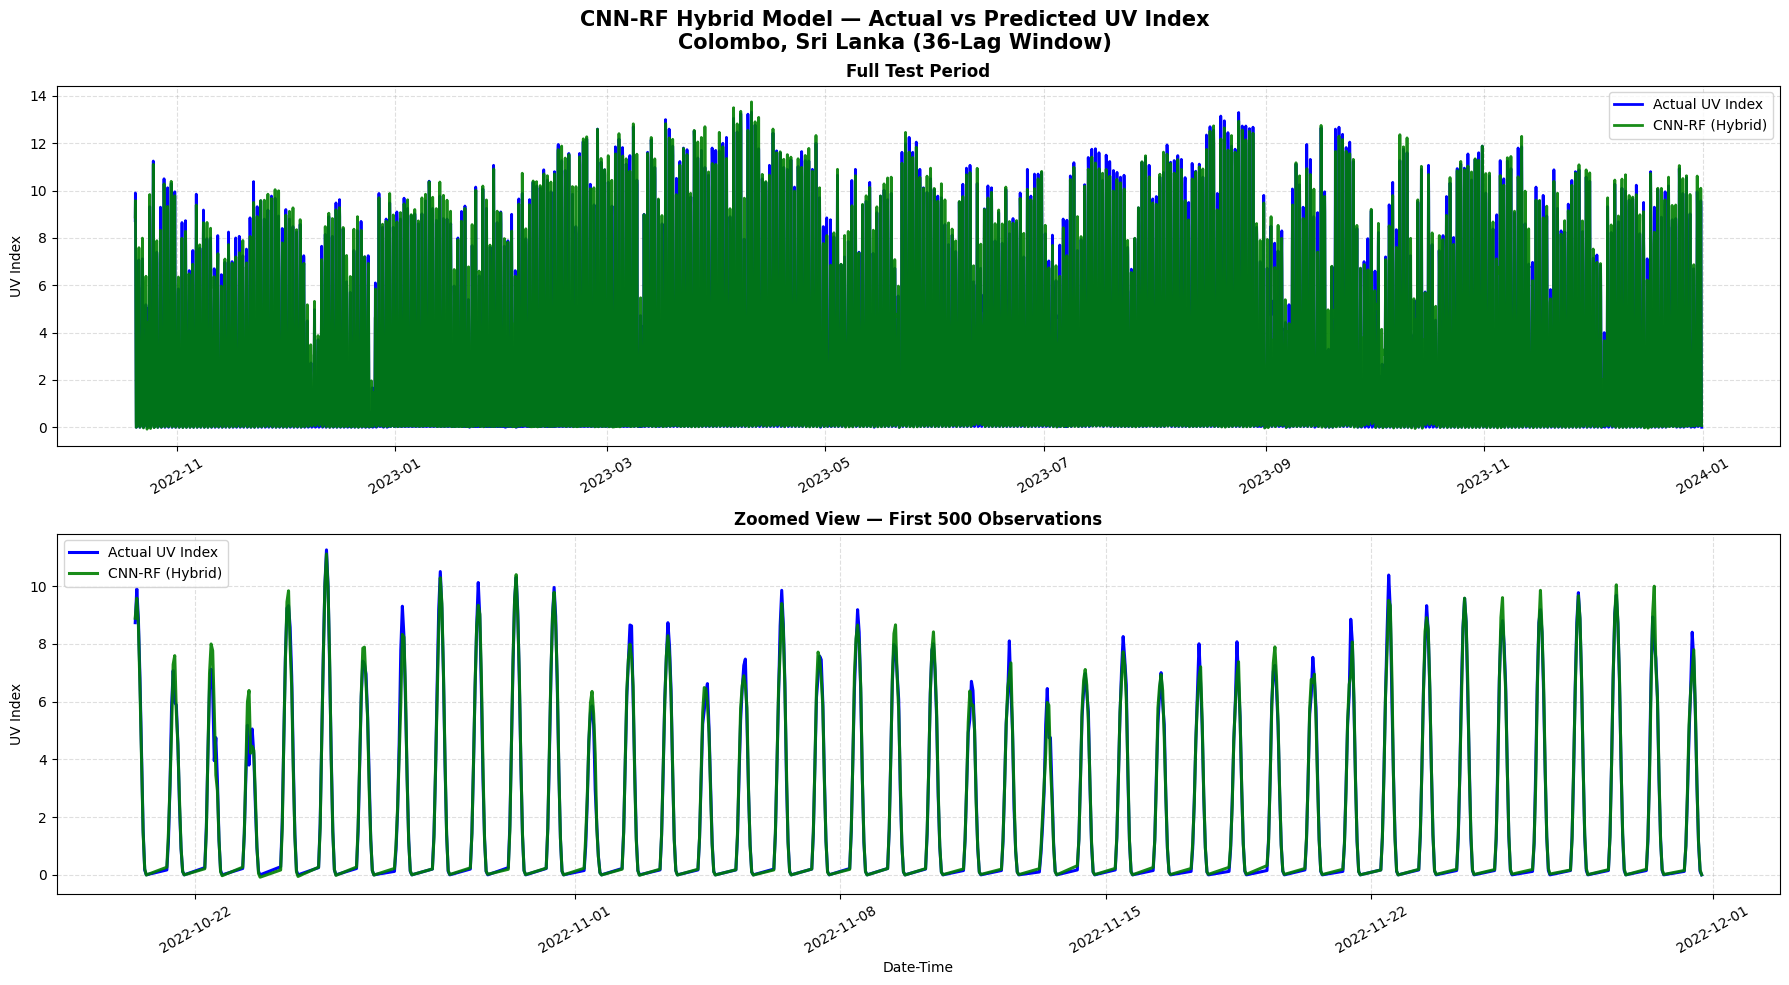

Saved → Fig_CNN_RF_Clean.png


In [10]:
import matplotlib.pyplot as plt

test_index = y_test.index
N_ZOOM = min(500, len(yts))

fig1, axes1 = plt.subplots(2, 1, figsize=(18, 10), sharex=False)

fig1.suptitle(
    'CNN-RF Hybrid Model — Actual vs Predicted UV Index\n'
    'Colombo, Sri Lanka (36-Lag Window)',
    fontsize=15, fontweight='bold'
)

# ── Top: full test set ─────────────────────────────────────
ax = axes1[0]

ax.plot(test_index, yts,
        color='blue', linewidth=2.0, label='Actual UV Index')

ax.plot(test_index, hybrid_rf_pred_test,
        color='green', linewidth=2.0,
        label='CNN-RF (Hybrid)', alpha=0.9)

ax.set_title('Full Test Period', fontsize=12, fontweight='bold')
ax.set_ylabel('UV Index')

ax.legend(loc='upper right')
ax.grid(True, linestyle='--', alpha=0.4)
ax.tick_params(axis='x', rotation=30)

# ── Bottom: zoom ───────────────────────────────────────────
ax2 = axes1[1]

ax2.plot(test_index[:N_ZOOM], yts[:N_ZOOM],
         color='blue', linewidth=2.2, label='Actual UV Index')

ax2.plot(test_index[:N_ZOOM], hybrid_rf_pred_test[:N_ZOOM],
         color='green', linewidth=2.2,
         label='CNN-RF (Hybrid)', alpha=0.9)

ax2.set_title(f'Zoomed View — First {N_ZOOM} Observations',
              fontsize=12, fontweight='bold')

ax2.set_ylabel('UV Index')
ax2.set_xlabel('Date-Time')

ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()

plt.savefig('Fig_CNN_RF_Clean.png',
            dpi=400, bbox_inches='tight')

plt.show()

print('Saved → Fig_CNN_RF_Clean.png')

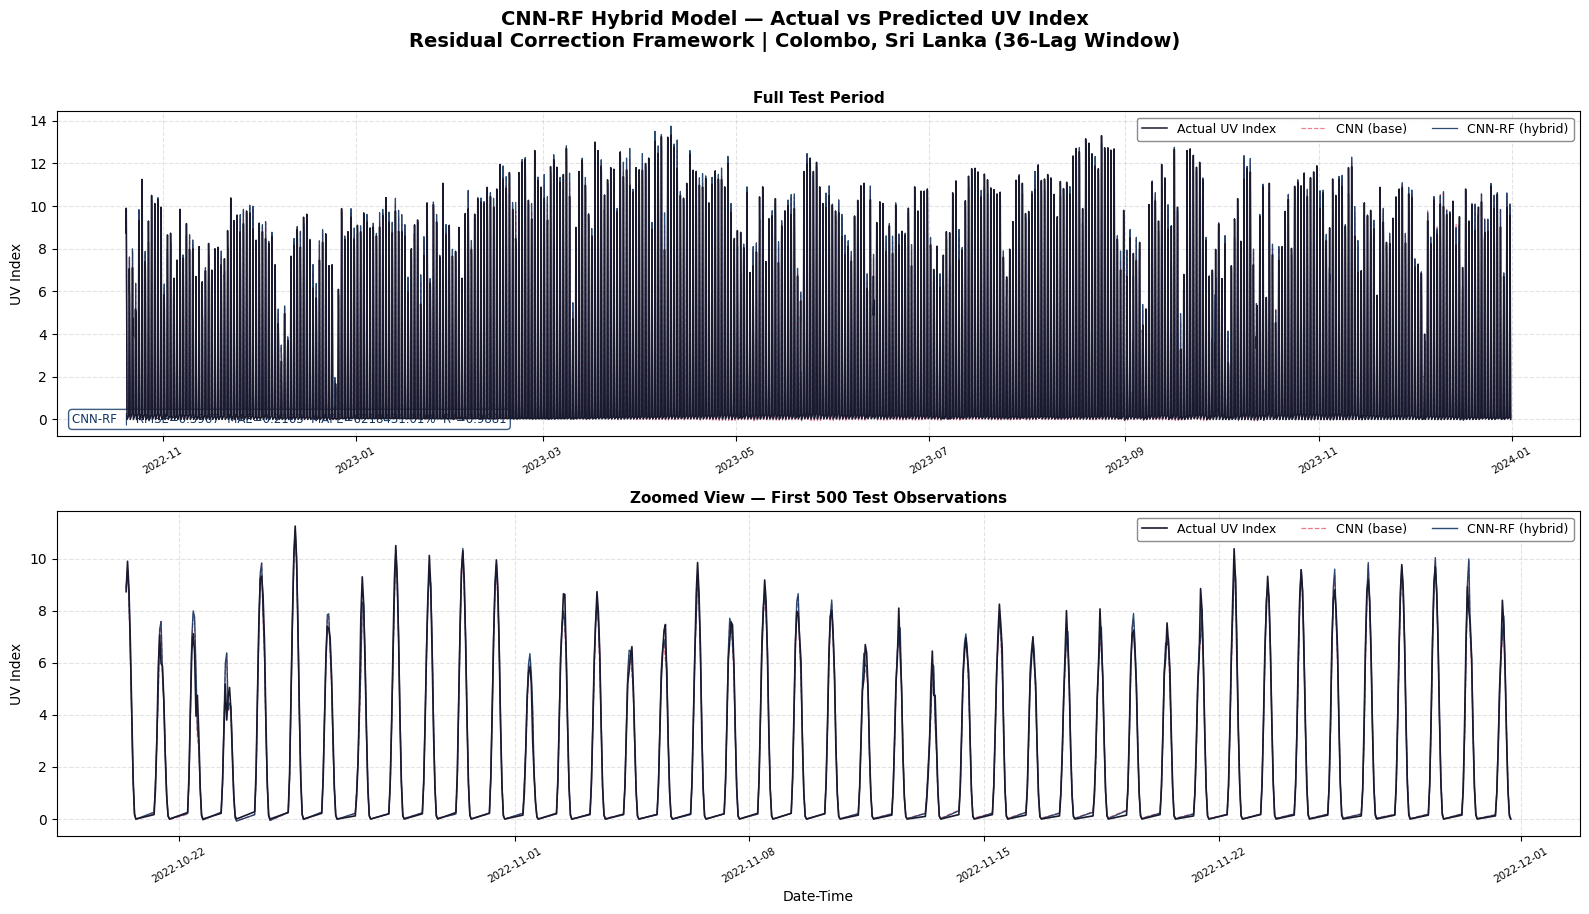

Saved → Fig_Hybrid_CNN_RF_ActualVsPredicted.png


In [11]:
test_index = y_test.index
N_ZOOM     = min(500, len(yts))

fig1, axes1 = plt.subplots(2, 1, figsize=(16, 9), sharex=False)
fig1.suptitle(
    'CNN-RF Hybrid Model — Actual vs Predicted UV Index\n'
    'Residual Correction Framework | Colombo, Sri Lanka (36-Lag Window)',
    fontsize=14, fontweight='bold', y=1.01
)

# ── Top: full test set ────────────────────────────────────────────────────────
ax = axes1[0]
ax.plot(test_index, yts,
        color='#1a1a2e', linewidth=1.1, label='Actual UV Index', zorder=5)
ax.plot(test_index, cnn_pred_test,
        color='#e94560', linewidth=0.85, linestyle='--', alpha=0.70,
        label='CNN (base)')
ax.plot(test_index, hybrid_rf_pred_test,
        color='#0f3460', linewidth=0.9, linestyle='-', alpha=0.88,
        label='CNN-RF (hybrid)')
ax.set_title('Full Test Period', fontsize=11, fontweight='bold')
ax.set_ylabel('UV Index', fontsize=10)
ax.legend(fontsize=9, loc='upper right', ncol=3, framealpha=0.9, edgecolor='grey')
ax.grid(True, linestyle='--', alpha=0.35)
ax.tick_params(axis='x', labelsize=7.5, rotation=30)
txt = (f'CNN-RF  |  RMSE={cnn_rf_metrics["RMSE"]:.4f}  '
       f'MAE={cnn_rf_metrics["MAE"]:.4f}  '
       f'MAPE={cnn_rf_metrics["MAPE"]:.2f}%  '
       f'R²={cnn_rf_metrics["R2"]:.4f}')
ax.annotate(txt, xy=(0.01, 0.04), xycoords='axes fraction', fontsize=8.5,
            color='#0f3460',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#0f3460', alpha=0.8))

# ── Bottom: zoom ──────────────────────────────────────────────────────────────
ax2 = axes1[1]
ax2.plot(test_index[:N_ZOOM], yts[:N_ZOOM],
         color='#1a1a2e', linewidth=1.2, label='Actual UV Index', zorder=5)
ax2.plot(test_index[:N_ZOOM], cnn_pred_test[:N_ZOOM],
         color='#e94560', linewidth=0.9, linestyle='--', alpha=0.75,
         label='CNN (base)')
ax2.plot(test_index[:N_ZOOM], hybrid_rf_pred_test[:N_ZOOM],
         color='#0f3460', linewidth=1.0, linestyle='-', alpha=0.88,
         label='CNN-RF (hybrid)')
ax2.set_title(f'Zoomed View — First {N_ZOOM} Test Observations',
              fontsize=11, fontweight='bold')
ax2.set_ylabel('UV Index', fontsize=10)
ax2.set_xlabel('Date-Time', fontsize=10)
ax2.legend(fontsize=9, loc='upper right', ncol=3, framealpha=0.9, edgecolor='grey')
ax2.grid(True, linestyle='--', alpha=0.35)
ax2.tick_params(axis='x', labelsize=7.5, rotation=30)

plt.tight_layout()
plt.savefig('Fig_Hybrid_CNN_RF_ActualVsPredicted.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved → Fig_Hybrid_CNN_RF_ActualVsPredicted.png')


## Cell 11 — Figure 2: Actual vs Predicted — CNN-XGB Hybrid
> Two-panel plot: full test period (top) + zoomed first 500 observations (bottom).


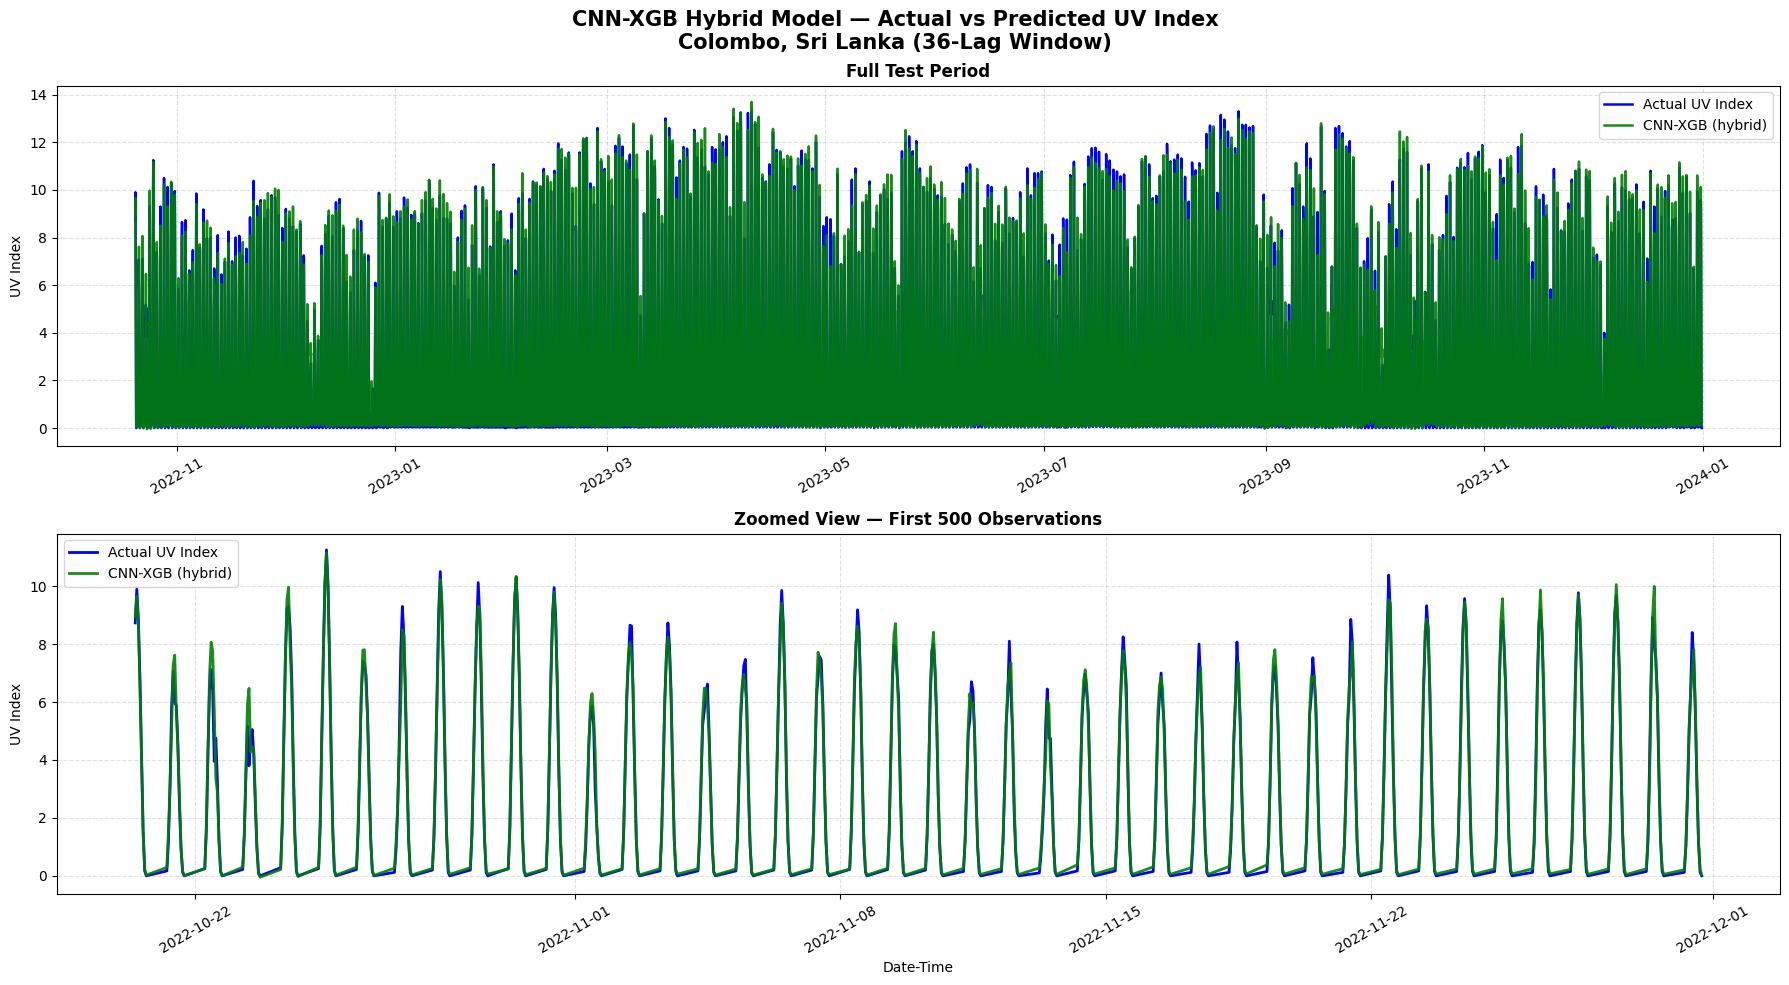

Saved → Fig_Hybrid_CNN_XGB_Clean.png


In [12]:
import matplotlib.pyplot as plt

fig2, axes2 = plt.subplots(2, 1, figsize=(18, 10), sharex=False)

fig2.suptitle(
    'CNN-XGB Hybrid Model — Actual vs Predicted UV Index\n'
    'Colombo, Sri Lanka (36-Lag Window)',
    fontsize=15, fontweight='bold'
)

# ── Top: full test set ─────────────────────────────────────
ax3 = axes2[0]

ax3.plot(test_index, yts,
         color='blue', linewidth=1.8, label='Actual UV Index')

ax3.plot(test_index, hybrid_xgb_pred_test,
         color='green', linewidth=1.8,
         label='CNN-XGB (hybrid)', alpha=0.9)

ax3.set_title('Full Test Period', fontsize=12, fontweight='bold')
ax3.set_ylabel('UV Index')

ax3.legend(loc='upper right')
ax3.grid(True, linestyle='--', alpha=0.4)
ax3.tick_params(axis='x', rotation=30)

# ── Bottom: zoom ───────────────────────────────────────────
ax4 = axes2[1]

ax4.plot(test_index[:N_ZOOM], yts[:N_ZOOM],
         color='blue', linewidth=2, label='Actual UV Index')

ax4.plot(test_index[:N_ZOOM], hybrid_xgb_pred_test[:N_ZOOM],
         color='green', linewidth=2,
         label='CNN-XGB (hybrid)', alpha=0.9)

ax4.set_title(f'Zoomed View — First {N_ZOOM} Observations',
              fontsize=12, fontweight='bold')

ax4.set_ylabel('UV Index')
ax4.set_xlabel('Date-Time')

ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.4)
ax4.tick_params(axis='x', rotation=30)

plt.tight_layout()

plt.savefig('Fig_Hybrid_CNN_XGB_Clean.png',
            dpi=400, bbox_inches='tight')

plt.show()

print('Saved → Fig_Hybrid_CNN_XGB_Clean.png')

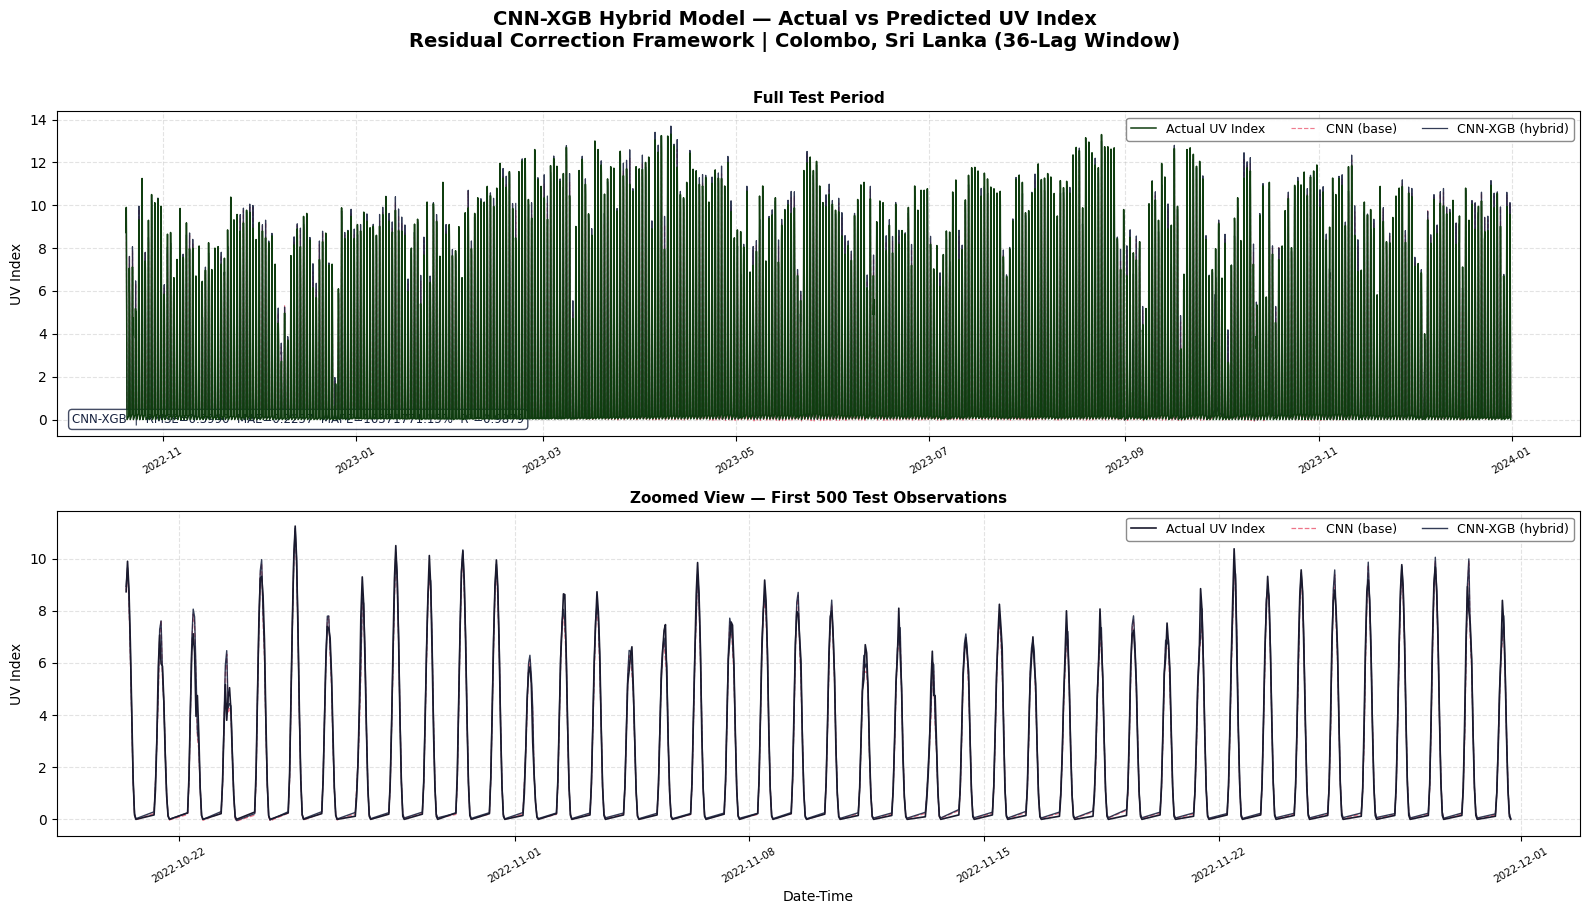

Saved → Fig_Hybrid_CNN_XGB_ActualVsPredicted.png


In [13]:
fig2, axes2 = plt.subplots(2, 1, figsize=(16, 9), sharex=False)
fig2.suptitle(
    'CNN-XGB Hybrid Model — Actual vs Predicted UV Index\n'
    'Residual Correction Framework | Colombo, Sri Lanka (36-Lag Window)',
    fontsize=14, fontweight='bold', y=1.01
)

# ── Top: full test set ────────────────────────────────────────────────────────
ax3 = axes2[0]
ax3.plot(test_index, yts,
         color='#0f3d0f', linewidth=1.1, label='Actual UV Index', zorder=5)
ax3.plot(test_index, cnn_pred_test,
         color='#e94560', linewidth=0.85, linestyle='--', alpha=0.70,
         label='CNN (base)')
ax3.plot(test_index, hybrid_xgb_pred_test,
         color='#16213e', linewidth=0.9, linestyle='-', alpha=0.88,
         label='CNN-XGB (hybrid)')
ax3.set_title('Full Test Period', fontsize=11, fontweight='bold')
ax3.set_ylabel('UV Index', fontsize=10)
ax3.legend(fontsize=9, loc='upper right', ncol=3, framealpha=0.9, edgecolor='grey')
ax3.grid(True, linestyle='--', alpha=0.35)
ax3.tick_params(axis='x', labelsize=7.5, rotation=30)
txt2 = (f'CNN-XGB  |  RMSE={cnn_xgb_metrics["RMSE"]:.4f}  '
        f'MAE={cnn_xgb_metrics["MAE"]:.4f}  '
        f'MAPE={cnn_xgb_metrics["MAPE"]:.2f}%  '
        f'R²={cnn_xgb_metrics["R2"]:.4f}')
ax3.annotate(txt2, xy=(0.01, 0.04), xycoords='axes fraction', fontsize=8.5,
             color='#16213e',
             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#16213e', alpha=0.8))

# ── Bottom: zoom ──────────────────────────────────────────────────────────────
ax4 = axes2[1]
ax4.plot(test_index[:N_ZOOM], yts[:N_ZOOM],
         color='#1a1a2e', linewidth=1.2, label='Actual UV Index', zorder=5)
ax4.plot(test_index[:N_ZOOM], cnn_pred_test[:N_ZOOM],
         color='#e94560', linewidth=0.9, linestyle='--', alpha=0.75,
         label='CNN (base)')
ax4.plot(test_index[:N_ZOOM], hybrid_xgb_pred_test[:N_ZOOM],
         color='#16213e', linewidth=1.0, linestyle='-', alpha=0.88,
         label='CNN-XGB (hybrid)')
ax4.set_title(f'Zoomed View — First {N_ZOOM} Test Observations',
              fontsize=11, fontweight='bold')
ax4.set_ylabel('UV Index', fontsize=10)
ax4.set_xlabel('Date-Time', fontsize=10)
ax4.legend(fontsize=9, loc='upper right', ncol=3, framealpha=0.9, edgecolor='grey')
ax4.grid(True, linestyle='--', alpha=0.35)
ax4.tick_params(axis='x', labelsize=7.5, rotation=30)

plt.tight_layout()
plt.savefig('Fig_Hybrid_CNN_XGB_ActualVsPredicted.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved → Fig_Hybrid_CNN_XGB_ActualVsPredicted.png')


## Cell 12 — Figure 3: Residual Distributions

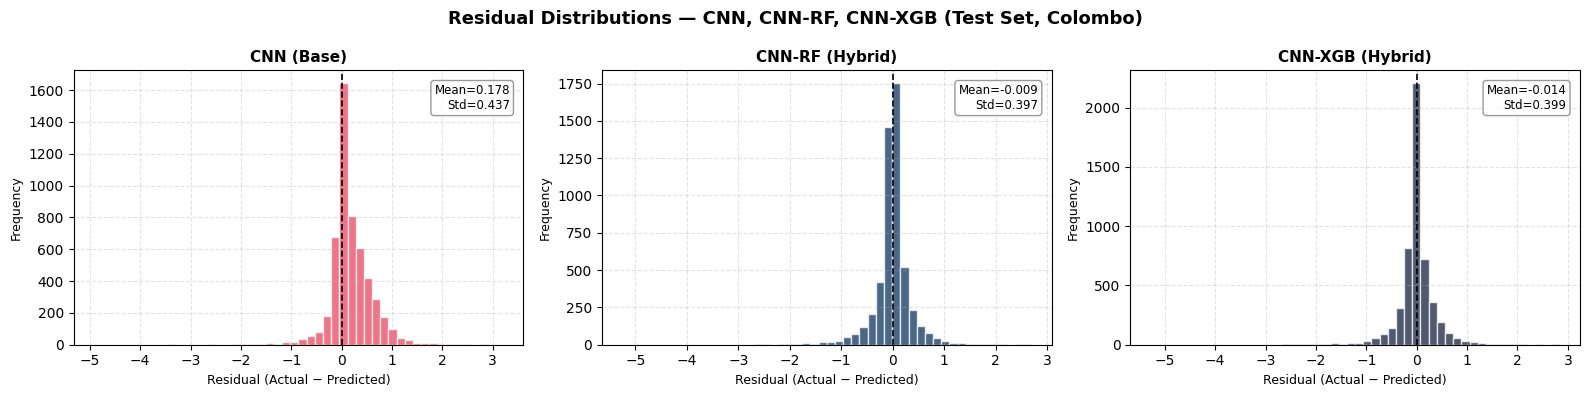

Saved → Fig_Hybrid_Residual_Distributions.png


In [14]:
res_cnn     = yts - cnn_pred_test
res_cnn_rf  = yts - hybrid_rf_pred_test
res_cnn_xgb = yts - hybrid_xgb_pred_test

fig3, axes3 = plt.subplots(1, 3, figsize=(16, 4))
fig3.suptitle(
    'Residual Distributions — CNN, CNN-RF, CNN-XGB (Test Set, Colombo)',
    fontsize=13, fontweight='bold'
)

for ax_r, res, title, color in zip(
    axes3,
    [res_cnn, res_cnn_rf, res_cnn_xgb],
    ['CNN (Base)', 'CNN-RF (Hybrid)', 'CNN-XGB (Hybrid)'],
    ['#e94560', '#0f3460', '#16213e'],
):
    ax_r.hist(res, bins=50, color=color, alpha=0.75, edgecolor='white')
    ax_r.axvline(0, color='black', linewidth=1.2, linestyle='--')
    ax_r.set_title(title, fontsize=11, fontweight='bold')
    ax_r.set_xlabel('Residual (Actual − Predicted)', fontsize=9)
    ax_r.set_ylabel('Frequency', fontsize=9)
    ax_r.annotate(
        f'Mean={res.mean():.3f}\nStd={res.std():.3f}',
        xy=(0.97, 0.95), xycoords='axes fraction',
        ha='right', va='top', fontsize=8.5,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='grey', alpha=0.8)
    )
    ax_r.grid(True, linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig('Fig_Hybrid_Residual_Distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved → Fig_Hybrid_Residual_Distributions.png')


## Cell 13 — Final Summary

In [15]:
print('\n' + '═' * 80)
print('  FINAL SUMMARY — Residual Correction Hybrid Models (Colombo, 36 Lags)')
print('═' * 80)

summary = [
    ['CNN (Base)',  '—',
     f'{cnn_metrics["MSE"]:.4f}',     f'{cnn_metrics["RMSE"]:.4f}',
     f'{cnn_metrics["MAE"]:.4f}',     f'{cnn_metrics["MAPE"]:.2f}',
     f'{cnn_metrics["R2"]:.4f}'],
    ['CNN-RF',      'RF',
     f'{cnn_rf_metrics["MSE"]:.4f}',  f'{cnn_rf_metrics["RMSE"]:.4f}',
     f'{cnn_rf_metrics["MAE"]:.4f}',  f'{cnn_rf_metrics["MAPE"]:.2f}',
     f'{cnn_rf_metrics["R2"]:.4f}'],
    ['CNN-XGB',     'XGB',
     f'{cnn_xgb_metrics["MSE"]:.4f}', f'{cnn_xgb_metrics["RMSE"]:.4f}',
     f'{cnn_xgb_metrics["MAE"]:.4f}', f'{cnn_xgb_metrics["MAPE"]:.2f}',
     f'{cnn_xgb_metrics["R2"]:.4f}'],
]
print(tabulate(summary,
               headers=['Model', 'Secondary', 'MSE', 'RMSE', 'MAE', 'MAPE (%)', 'R²'],
               tablefmt='grid'))

print('\n  Output files:')
for f in [
    'Table_Hybrid_Performance_Colombo.csv',
    'Table_Hybrid_Hyperparameters_Colombo.csv',
    'Fig_Hybrid_CNN_RF_ActualVsPredicted.png',
    'Fig_Hybrid_CNN_XGB_ActualVsPredicted.png',
    'Fig_Hybrid_Residual_Distributions.png',
]:
    print(f'    {f}')
print('\n✅ All done.')



════════════════════════════════════════════════════════════════════════════════
  FINAL SUMMARY — Residual Correction Hybrid Models (Colombo, 36 Lags)
════════════════════════════════════════════════════════════════════════════════
+------------+-------------+--------+--------+--------+-------------+--------+
| Model      | Secondary   |    MSE |   RMSE |    MAE |    MAPE (%) |     R² |
+============+=============+========+========+========+=============+========+
| CNN (Base) | —           | 0.2224 | 0.4716 | 0.3052 | 9.83536e+06 | 0.9831 |
+------------+-------------+--------+--------+--------+-------------+--------+
| CNN-RF     | RF          | 0.1573 | 0.3967 | 0.2163 | 6.21843e+06 | 0.9881 |
+------------+-------------+--------+--------+--------+-------------+--------+
| CNN-XGB    | XGB         | 0.1592 | 0.399  | 0.2257 | 1.63718e+07 | 0.9879 |
+------------+-------------+--------+--------+--------+-------------+--------+

  Output files:
    Table_Hybrid_Performance_Colombo.c

## Cell 14 — Diebold-Mariano Test: CNN-RF vs CNN-XGB
> Tests whether the two hybrid models produce **statistically significantly different** forecast errors.  
> **H₀:** Both models have equal predictive accuracy (E[d_t] = 0)  
> **H₁:** The models differ in predictive accuracy  
> A significant result (p < 0.05) means one model is statistically superior to the other.

In [16]:
# ── Cell 14 — Diebold-Mariano Test: CNN-RF vs CNN-XGB ────────────────────────
from scipy import stats
import numpy as np

print('=' * 68)
print('  DIEBOLD-MARIANO TEST — CNN-RF vs CNN-XGB Hybrid')
print('  H₀: Both models have equal predictive accuracy')
print('  H₁: The models differ in predictive accuracy')
print('=' * 68)

# ── Step 1: Compute squared forecast errors ───────────────────────────────────
e_rf  = np.array(yts) - np.array(hybrid_rf_pred_test)   # CNN-RF errors
e_xgb = np.array(yts) - np.array(hybrid_xgb_pred_test)  # CNN-XGB errors

# Loss differential: d_t = L(e_rf_t) - L(e_xgb_t)  using squared error loss
d = e_rf**2 - e_xgb**2

# ── Step 2: DM statistic ──────────────────────────────────────────────────────
# DM = d̄ / sqrt(Var(d̄))   where Var accounts for autocorrelation via Newey-West
n    = len(d)
d_bar = np.mean(d)

# Newey-West HAC variance (bandwidth h-1 where h is forecast horizon; use h=1)
h = 1   # one-step-ahead forecasts
gamma_0 = np.var(d, ddof=1)

# Autocovariances up to lag h-1
gamma_sum = 0.0
for k in range(1, h):
    gamma_k = np.mean((d[k:] - d_bar) * (d[:-k] - d_bar))
    gamma_sum += 2 * (1 - k / h) * gamma_k

var_d_bar = (gamma_0 + gamma_sum) / n
DM_stat   = d_bar / np.sqrt(var_d_bar)

# ── Step 3: p-value (two-tailed, standard normal) ────────────────────────────
p_value = 2 * (1 - stats.norm.cdf(abs(DM_stat)))

# ── Step 4: Mean loss values for context ─────────────────────────────────────
mean_sq_err_rf  = np.mean(e_rf**2)
mean_sq_err_xgb = np.mean(e_xgb**2)

print(f'\n  Mean Squared Error — CNN-RF  : {mean_sq_err_rf:.6f}')
print(f'  Mean Squared Error — CNN-XGB : {mean_sq_err_xgb:.6f}')
print(f'  Loss differential (d̄)       : {d_bar:+.6f}')
print(f'  DM Statistic                 : {DM_stat:.4f}')
print(f'  p-value (two-tailed)         : {p_value:.4f}')

# ── Step 5: Decision ─────────────────────────────────────────────────────────
alpha = 0.05
print(f'\n  Significance level (α)       : {alpha}')
print()
print('─' * 68)
if p_value < alpha:
    better = 'CNN-RF' if mean_sq_err_rf < mean_sq_err_xgb else 'CNN-XGB'
    print(f'  DECISION: Reject H₀  (p = {p_value:.4f} < α = {alpha})')
    print(f'  ✔ There IS a statistically significant difference in predictive')
    print(f'    accuracy between the two hybrid models.')
    print(f'  ✔ {better} is the statistically superior model (lower MSE).')
else:
    print(f'  DECISION: Fail to reject H₀  (p = {p_value:.4f} ≥ α = {alpha})')
    print(f'  ✘ There is NO statistically significant difference in predictive')
    print(f'    accuracy between CNN-RF and CNN-XGB at the 5% level.')
    print(f'    Both models are considered equally accurate.')
print('─' * 68)


  DIEBOLD-MARIANO TEST — CNN-RF vs CNN-XGB Hybrid
  H₀: Both models have equal predictive accuracy
  H₁: The models differ in predictive accuracy

  Mean Squared Error — CNN-RF  : 0.157341
  Mean Squared Error — CNN-XGB : 0.159185
  Loss differential (d̄)       : -0.001845
  DM Statistic                 : -2.2447
  p-value (two-tailed)         : 0.0248

  Significance level (α)       : 0.05

────────────────────────────────────────────────────────────────────
  DECISION: Reject H₀  (p = 0.0248 < α = 0.05)
  ✔ There IS a statistically significant difference in predictive
    accuracy between the two hybrid models.
  ✔ CNN-RF is the statistically superior model (lower MSE).
────────────────────────────────────────────────────────────────────


## Utility — Clear Checkpoints (retrain from scratch)

In [17]:
# ⚠️  Uncomment and run ONLY if you want to delete checkpoints and retrain

# import glob
# for f in glob.glob('checkpoint_hybrid/*.pkl'):
#     os.remove(f)
#     print(f'Deleted: {f}')
# print('Checkpoints cleared — re-run Cells 6–7 to retrain.')
